# Guía de Trabajo Práctico 1 

**Materia**: Aprendizaje Profundo Basado en la Física (optativa del Instituto Balseiro)

**Docente**: José I. Robledo

**Edición**: abril-mayo 2026

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/practicos/Guia_Semana_01_Fundamentos_Python_y_ML.ipynb)

## Parte 1 - Introducción a la programación orientada a objetos en Python             


## Imports

In [1]:
from __future__ import annotations

from random import Random
import matplotlib.pyplot as plt
import numpy as np

---

## Ejercicio 1 - Clase `Medicion`

Supongamos que queremos representar una medicion simple de un experimento. Para esto utilizaremos una clase y veremos la ventaja de la programación orientada a objetos que ofrece Python. Supongamos que medimos el valor una variable en su correspondiente unidad (podría ser peso en Kg, temperatura en Kelvin, largo en cm, lo que se te ocurra).

1. Crear una *clase* `Medicion` con *atributos*:
   - `nombre_variable` (str)
   - `valor` (float)
   - `unidad` (str)
2. Implementar:
   - `__repr__` para que la instancia sea facil de inspeccionar
   - `es_positiva()` que devuelva `True` si `valor` es un numero no negativo
   - `to_dict()` que devuelva un diccionario con la informacion de la medicion
3. Crear al menos 3 mediciones distintas y mostrarlas.


In [ ]:
# TODO: definir la clase Medicion
# TODO: crear 3 instancias
# TODO: imprimirlas y verificar su correcto funcionamiento


---

## Ejercicio 2 - Clase `SerieDeMediciones`

Ahora queremos agrupar mediciones de una misma variable y exponer metodos utiles para la serie de mediciones. Además, queremos asegurar que sólo podamos agrupar mediciones del mismo tipo.

1. Crear una clase `SerieDeMediciones` que reciba:
   - `nombre`
   - una lista opcional de objetos `Medicion`
2. Implementar los *métodos*:
   - `agregar(medicion)`: agrega instancia de `Medición` a la lista de mediciones.
   - `eliminar(medicion)`: elimina una medición de la lista a partir de su índice posicional.
   - `valores()`: devuelve una lista con los valores numericos de todas las mediciones en la lista. 
   - `promedio()`: calcula el promedio muestral de los valores numéricos de la lista de mediciones como $\sum_{i=1}^{N} x_i /N$.
   - `desvio_estandar()`: calcula el desvío estándar muestral como $\sum_{i=1}^{N-1} (x_i - \bar x)^2/(N-1)$
   - `minimo()`: Calcula el mínimo de los valores numéricos de la lista de mediciones.
   - `maximo()`: Calcula el máximo de los valores numéricos de la lsita de mediciones.
   - `resumen()`: devuelve un diccionario con la cantidad de mediciones, el valor promedio, el mínimo y el máximo
3. Verificar que no se puedan agregar objetos de tipo incorrecto.
4. Crear una serie con al menos 5 mediciones de temperatura y probar todos los *métodos* implementados.


In [ ]:
# TODO: definir SerieDeMediciones
# TODO: crear una serie de temperaturas
# TODO: probar resumen y asserts


---

## Ejercicio 3 - Clase `DatasetRegresion`

### Modelado con Clausius–Clapeyron

En la termodinámica del agua, la ecuación de Clausius–Clapeyron relaciona la presión de vapor de saturación con la temperatura:

$$
\ln P = -\frac{L}{R_v T} + C
$$

donde:
- \(P\) es la presión de vapor de saturación (Pa),
- \(T\) es la temperatura absoluta (K),
- \(L\) es la entalpía de vaporización (J/kg),
- \(R_v\) es la constante de gas del vapor de agua (J/(kg·K)),
- \(C\) es una constante relacionada con el estado.

Reordenando, se puede obtener una expresión aproximada para \(T\) en función de \(P\):

$$
T \approx \frac{L}{R_v (C - \ln P)}
$$

Usaremos esta relación como una forma física de generar datos sintéticos de temperatura dependientes de la presión, y añadiremos un término adicional de ruido para hacer el dataset más realista y adecuado para un problema de regresión.  

Vamos a representar un dataset pequeno para regresion 1D. Para el problema de regresión, necesitamos que cada muestra tenga:
- una valor de `presion` como variable medida
- un valor de temperatura `T` como respuesta

1. Crear una clase `DatasetRegresion` que almacene los datos. Cada muestra puede representarse como diccionario o como objeto propio.
2. Implementar:
   - `agregar_muestra(x, y)`
   - `features()` que devuelva la lista de `x`
   - `targets()` que devuelva la lista de `y`
   - `__len__()`
   - `train_test_split(test_size=0.2, seed=42)` que separe al conjunto de datos en una parte de entrenamiento y otra de prueba y devuelva dos instancias de `DatasetRegression` de las particiones.
3. Revisar la generación de dataset sintético con una regla aproximada tipo `T = L/(R_v*(C - np.log(P_pa + 1e-8))) - 273.15 + ruido` para presiones entre 850hPa y 1050hPa usando `ruido` aleatorio uniforme entre -1.5 y 1.5. Para toda instancia aleatoria, tener en cuenta una semilla con `Random(seed)`.
4. Separar en train y test en 75% para entrenamiento y 25% para prueba y mostrar cuantos elementos hay en cada uno.


In [19]:
# TODO: definir DatasetRegresion

# Generar datos sinteticos reproducibles
rng = Random(7)
presiones, temperaturas = [], []
for _ in range(100):
    presion = rng.uniform(850, 1050)
    presiones.append(presion)
    ruido = rng.uniform(-1.5, 1.5)

    # Relación inspirada en Clausius–Clapeyron (vapor de agua)
    P_pa = presion * 100.0
    L = 2.26e6  # J/kg, latente de vaporización del agua
    R_v = 461.5  # J/(kg·K), gas constante del vapor de agua
    C = 20.0

    # Temperatura (K) del vapor saturado igualada con la ecuación de Clausius-Clapeyron
    # y convertida a °C.
    T_k = L / (R_v * (C - np.log(P_pa + 1e-8)))
    temperatura = T_k - 273.15 +  ruido
    temperaturas.append(temperatura)

# TODO: hacer split train/test
# TODO: imprimir tamanos y algun ejemplo


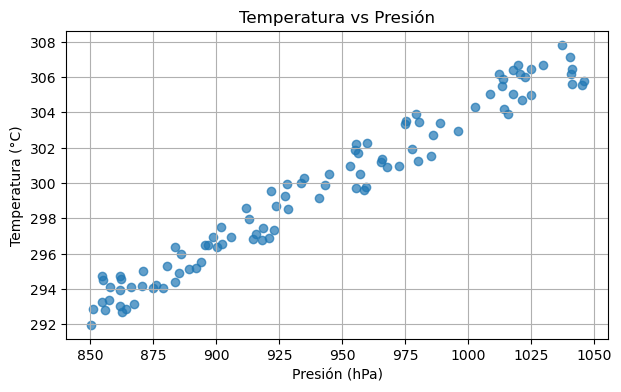

In [20]:
plt.figure(figsize=(7, 4))
plt.scatter(presiones, temperaturas, alpha=0.7)
plt.xlabel('Presión (hPa)')
plt.ylabel('Temperatura (°C)')
plt.title('Temperatura vs Presión')
plt.grid(True)
plt.show()

---

## Ejercicio 4 - Modelo con interfaz `fit` / `predict`

Queremos una clase que aprenda una recta a partir de datos 1D usando una fórmula cerrada de mínimos cuadrados.

1. Crear una clase `RegresionLinealSimple` con *atributos* `pendiente` e `intercepto`.
2. Implementar:
   - `fit(xs, ys)` para estimar la recta `y = m*x + b`
   - `predict(xs)` que reciba una lista de entradas y devuelva una lista de predicciones
   - `predict_one(x)` para un valor escalar
3. Entrenar el modelo sobre el dataset train del ejercicio anterior.
4. Mostrar `pendiente` e `intercepto` aprendidos.
5. Graficar la predicción sobre el conjunto de datos de entrenamiento, y luego la predicción usando los datos de prueba.
6. Opcional: Realizar el ejercicio utilizando [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) de `scikit-learn`.
   
### Ecuaciones de Mínimos Cuadrados

- Media:
  $$\bar x = \frac{1}{n} \sum_{i=1}^{n} x_i, \qquad \bar y = \frac{1}{n} \sum_{i=1}^{n} y_i$$

- Pendiente:
  $$m = \frac{\sum_{i=1}^{n} (x_i - \bar x)(y_i - \bar y)}{\sum_{i=1}^{n} (x_i - \bar x)^2}$$

- Intercepto:
  $$b = \bar y - m\,\bar x$$

- Predicción:
  $$\hat y = m x + b$$


In [ ]:
# TODO: definir RegresionLinealSimple
# TODO: entrenar con train.features() y train.targets()
# TODO: imprimir parámetros y algunas predicciones
# TODO: graficar predicción con datos de entrenamiento y de prueba.


---

## Ejercicio 5 - Clase `MetricasRegresion`

Vamos a separar la logica del modelo de la logica de evaluacion.

1. Crear una clase `MetricasRegresion` con métodos estáticos:
   - `mse(y_true, y_pred)`
   - `mae(y_true, y_pred)`
   - `r2(y_true, y_pred)`
2. Evaluar el modelo del ejercicio 4 sobre el conjunto de test.
3. Mostrar los valores obtenidos con 4 decimales.
4. Explicar en 3 a 6 lineas por que tiene sentido que las metricas no vivan dentro del modelo.

**Puente conceptual:** esto conecta directamente con `sklearn.metrics`.

Aquí tenés el contenido en **Markdown** listo para el enunciado:

---

## Ejercicio 5 - Clase `MetricasRegresion`

Vamos a separar la lógica del modelo de la lógica de evaluación.

1. Crear una clase `MetricasRegresion` con métodos estáticos:

   * `mse(y_true, y_pred)`
   * `mae(y_true, y_pred)`
   * `r2(y_true, y_pred)`

2. Evaluar el modelo del ejercicio 4 sobre el conjunto de test.

3. Mostrar los valores obtenidos con 4 decimales.

---

### Definición de métricas

Las métricas de regresión se definen de la siguiente manera:

* **Error Cuadrático Medio (MSE)**
$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

* **Error Absoluto Medio (MAE)**
$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

* **Coeficiente de Determinación (R²)**
$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$

donde:

* $y_i$ son los valores reales
* $\hat{y}_i$ son las predicciones del modelo
* $\bar{y}$ es el promedio de los valores reales
* $n$ es la cantidad de muestras


In [ ]:
# TODO: definir MetricasRegresion
# TODO: evaluar en test
# TODO: imprimir metricas con formato

<!-- TODO (Markdown): explicar por que las metricas conviene separarlas del modelo -->

---

## Ejercicio 6 - Clase `Experimento`

Ahora queremos una clase de mas alto nivel que coordine dataset, modelo y resultados.

1. Crear una clase `ExperimentoRegresion` que reciba:
   - `nombre`
   - `dataset_train`
   - `dataset_test`
   - `modelo`
2. Implementar un metodo `ejecutar()` que:
   - entrene el modelo
   - compute predicciones en train y test
   - guarde un atributo `historial` como lista de diccionarios con metricas
3. Implementar `reporte()` que devuelva un string legible con el resumen del experimento.
4. Ejecutar el experimento y mostrar el reporte.

In [ ]:
# TODO: definir ExperimentoRegresion
# TODO: ejecutar experimento y mostrar reporte
# TODO: inspeccionar historial


<!-- TODO (Markdown): explicar el puente hacia numpy, matplotlib, sklearn y pytorch -->

---
---
## Parte 2 - Introduccion a NumPy y Matplotlib



In [ ]:
from __future__ import annotations

from random import Random
from time import perf_counter

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4)


## Ejercicio 7 - Obtener arrays desde las clases de mediciones y dataset

1. Construir `temp_array` como array de `numpy` a partir de `serie_temp.valores()`.
2. Obtener `x_train`, `y_train`, `x_test`, `y_test` como arrays de numpy a partir de `train_ds` y `test_ds`. 
3. Construir `XY_train` como array de numpy de dimensión `(n_train, 2)` apilando `x_train` e `y_train` por columnas. Practicar `slicing`: para cada uno de los siguientes enunciados, crear una nueva variable a partir de `XY_train` (e imprimir su dimensión) que contenga:
   - los primeros 20 elementos de `x`.
   - los últimos 20 elementos de `y`.
   - la multiplicación de los dos arrays anteriores mediante `*`. Analizar qué significa esta operación. 
   - el logaritmo de los primeros 20 elementos de `x`. 
   - los pares `(x,y)` con índice par.
   - el vector `y`.
   - un subconjunto aleatorio de 25 elementos `(x,y)` de `xy_train`.
4. Imprimir para todos los arrays construídos: `shape`, `dtype`, `ndim`, `size`.
5. Verificar que:
   - la dimensión de `temp_array` es 1: `temp_array.ndim == 1`
   - los tamaños de `x_train` y `y_train` son iguales: `x_train.shape == y_train.shape`
   - La segunda dimensión de `XY_train` contiene dos entradas: `XY_train.shape[1] == 2`

In [ ]:
# TODO: construir temp_array, x_train, y_train, x_test, y_test
# TODO: armar XY_train
# TODO: realizar operaciones con XY_train 
# TODO: imprimir propiedades
# TODO: verificaciones

---
## Ejercicio 8 - Beneficio de usar NumPy
Vamos a comparar una operacion equivalente hecha con listas de Python y con arrays de `numpy`, usando los datos anteriores.

1. Partir de `serie_temp.valores()` y construir una lista larga `temps_grandes_lista` repitiendo esas mediciones muchas veces (por ejemplo 200_000 repeticiones).
2. Construir `temps_grandes_array` como `np.array(temps_grandes_lista)`.
3. centrar los datos respecto al valor promedio (calcular y restar el valor promedio):
   - con listas Python
   - con NumPy
4. Medir tiempos con [`perf_counter()`](https://docs.python.org/3/library/time.html#module-time) para ambas variantes.
5. Verificar con [`np.allclose`](https://numpy.org/devdocs/reference/generated/numpy.allclose.html) que ambas producen el mismo resultado.
6. Reportar:
   - tiempo con listas
   - tiempo con NumPy
   - factor aproximado de mejora

In [ ]:
# TODO: crear temps_grandes_lista y temps_grandes_array
# TODO: calcular la version centrada con listas
# TODO: calcular la version centrada con NumPy
# TODO: medir tiempos y comparar resultados


---

## Ejercicio 9 - Vectorización en NumPy

Ya tenemos `modelo` entrenado  en el Ejercicio 4. Ahora vamos a usar su pendiente e intercepto con numpy arrays.

1. Construir `y_hat_train_np` y `y_hat_test_np` usando la formula vectorizada:
$$
\hat{T} = m \cdot P + b
$$ 

donde `m` y `b` son la pendiente y el intercepto estimadas por el modelo y P el vector de entrenamiento en formato de array de numpy.

2. Obtener las predicciones del modelo para train y test.
3. Verificar que las predicciones vectorizadas y las del modelo coinciden.
4. Calcular el error cuadrático medio (MSE) para los conjuntos en entrenamiento y prueba en forma vectorizada.
5. Mostrar las primeras predicciones de ambos enfoques para train.

In [ ]:
# TODO: usar pendiente e intercepto de modelo sobre arrays
# TODO: comparar contra predict del modelo 
# TODO: calcular mse_train y mse_test vectorizados
# TODO: imprimir resultados


---

## Ejercicio 10 - Reobtener el mismo ajuste con álgebra lineal de NumPy

Ahora queremos reproducir el ajuste lineal usando `numpy.linalg.lstsq`.


1. Construir la matriz de diseño `A_train = [x_train, 1]`.
2. Resolver el problema de mínimos cuadrados con [`np.linalg.lstsq`](https://numpy.org/devdocs/reference/generated/numpy.linalg.lstsq.html).
3. Obtener `m_hat_np` y `b_hat_np`.
4. Comparar esos parámetros con `modelo.pendiente` y `modelo.intercepto` de los ejercicios anteriores.
5. Verificar con `np.allclose` que ambos ajustes son equivalentes dentro de una tolerancia razonable.
6. Calcular `y_hat_test_lstsq` y el `mae_test_lstsq`.


In [ ]:
# TODO: armar A_train, útil: np.ones_like 
# TODO: resolver lstsq
# TODO: comparar parametros con el ajuste de RegresionLinealSimple
# TODO: calcular predicciones y MAE en test

<!-- TODO (Markdown): explicar la ventaja de resolver el ajuste con algebra lineal -->

---

## Ejercicio 11 - Visualizar datos y ajuste con Matplotlib

Explorar la capacidad de la librería [`matplotlib`](https://matplotlib.org/) para graficar.

1. Graficar los puntos de train y test en un mismo gráfico con colores distintos.
2. Superponer la recta del ajuste obtenido por el modelo de regresión inicial.
3. Agregar título, ejes y leyenda.
4. En una segunda figura, graficar los residuos en el conjunto de prueba:
$$
r_i = y_i - \hat{y}_i
$$
5. Verificar visualmente si el ajuste parece razonable.


In [ ]:
# TODO: scatter de train y test
# TODO: recta del ajuste de POO
# TODO: grafico de residuos en test


<!-- TODO (Markdown): explicar el beneficio de graficar historiales como arrays -->

---
---

## Parte 3 - Introduccion a PyTorch

In [ ]:

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

---

## Ejercicio 12 — Tensores: creación, dtypes, shapes y dispositivos


1. Crear los siguientes tensores:
   - `t0`: tensor 1D con valores [100, 0, 25.6] como (`float32`) usando `torch.tensor`
   - `a`: tensor 1D con valores `[0,1,2,...,9]` (`int64`) usando `torch.arange`
   - `b`: tensor 2D de shape `(3,4)` con valores aleatorios uniformes en `[0,1)` (`float32`) utilizando `torch.rand`
   - `c`: tensor 3D de shape `(2,3,4)` lleno de unos utilizando `torch.ones`
2. Crear una función llamada `mostrar_info` que reciba un tensor e imprima su
   - `dtype`, `shape`, `device`, `requires_grad`

   Utilizar la función para cada tensor creado anteriormente.

3. Convertir `a` a `float32` utilizando el método de los tensores `.to()` y normalizarlo a media 0 y desvío 1 utilizando los métodos `.mean()` y `.std()`.
4. Mover `b` a GPU **si tiene GPU disponible** utilizando el método `.to()`; si no, dejarlo en CPU.

In [ ]:
# TODO: crear t0, a, b, c
# TODO: imprimir propiedades
# TODO: convertir/normalizar a
# TODO: mover b a CUDA si existe

---

## Ejercicio 13 — Indexing, slicing, broadcasting y operaciones básicas

1. Crear un tensor `X` con valores `0,1,...,29` y reacomodarlo a dimensión `(5, 6)` utilizando el método `.view()` de los tensores de pytorch.
2. Extraer:
   - la tercera fila (índice 2) completa
   - la quinta columna (índice 4) completa
   - un sub-bloque de 3x2 (filas 1..3, columnas 2..3)
3. Crear un vector `v` de dimensión `(6,)` y sumar `X + v` usando broadcasting.
4. Verificar con asserts:
   - que `X + v` tiene shape `(5,6)`
   - que la fila 0 de `X+v` coincide con `X[0] + v`
5. crear un tensor con elementos enteros aleatorios entre -10 y 10, de dimensión (10,8,2)

In [ ]:

# TODO: crear X con shape (5,6)
# TODO: slicing solicitado
# TODO: broadcasting con v
# TODO: asserts
# TODO(opcional): view vs reshape vs transpose

---

## Ejercicio 14 — Autograd: gradientes y verificación numérica simple

1. Definir un tensor `x` escalar con `requires_grad=True` e inicializarlo con algún valor (ej. 1.5).
2. Definir la función:
$$
f(x) = x^3 + 2x^2 - 5x + 1
$$
3. Calcular `f(x)` y obtener `df/dx` usando `backward()`.
4. Verificar aproximadamente el gradiente usando diferencias finitas:

$$
f'(x) \approx \frac{f(x+\epsilon) - f(x-\epsilon)}{2\epsilon}
$$

con `epsilon = 1e-4`.

5. Reportar (en Markdown) el error absoluto entre autograd y diferencias finitas.

In [ ]:

# TODO: definir x con requires_grad=True
# TODO: definir f(x) y backward
# TODO: gradiente por diferencias finitas
# TODO: comparar y reportar error absoluto

---

## Ejercicio 15 — `nn.Module`: construir un modelo y contar parámetros

1. Implementar una clase `MLP` (heredando de `nn.Module`) con:
   - `Linear(in_features=10, out_features=32)`
   - `ReLU`
   - `Linear(32, 1)`
2. Crear una instancia del modelo y:
   - imprimir el modelo
   - contar parámetros entrenables (total) y mostrar el número
3. Hacer un paso hacia adelante de la red (forward pass) con un batch sintético `X` de shape `(16, 10)` y chequear que la salida tiene shape `(16, 1)`.
4. Explicar brevemente (Markdown): diferencia entre `model.parameters()` y `state_dict()`.

In [ ]:

# TODO: definir MLP(nn.Module)
# TODO: instanciar, imprimir, contar parámetros
# TODO: forward con batch sintético y assert de shape
# TODO: breve explicación en Markdown (en celda aparte)

<!-- TODO (Markdown): escribir acá tu explicación de parameters() vs state_dict() -->

---

## Ejercicio 16 — Entrenamiento básico: loop, `optim`, `train()`/`eval()`


Vamos a entrenar un modelo simple en un dataset sintético de regresión:
$$
y = 3x + 0.5 + \text{ruido}
$$
donde \(x\) es 1D.


1. Generar datos sintéticos:
   - `N=512` puntos
   - `x` uniforme en `[-2, 2]`
   - ruido Gaussiano con `std=0.2`
2. Definir un modelo `nn.Linear(1,1)`.
3. Elegir:
   - pérdida MSE (`nn.MSELoss`)
   - optimizador SGD (`torch.optim.SGD`) con `lr` razonable
4. Implementar loop de entrenamiento por `epochs=300`:
   - usar `model.train()`
   - `zero_grad()`, forward, loss, `backward()`, `step()`
   - loggear la loss cada 50 épocas
5. Al final, imprimir los parámetros aprendidos (`weight`, `bias`) y compararlos con (3, 0.5).

4. (Opcional) correr un paso con `model.eval()` y `torch.no_grad()` para predecir 5 valores.

In [ ]:
# TODO: generar dataset sintético (x, y) como tensores float32 con shape (N,1)
# TODO: definir modelo nn.Linear(1,1), loss y optimizer
# TODO: loop de entrenamiento con logs
# TODO: imprimir weight/bias aprendidos y comparar
# TODO(extra): eval + no_grad, predicciones

---

## Ejercicio 17 — `Dataset` y `DataLoader`: batching, shuffle y collation

1. Crear una clase `ToyDataset(Dataset)` que:
   - reciba tensores `X` e `y`
   - implemente `__len__` y `__getitem__`
2. Reutilizar los datos sintéticos del Ejercicio 16 y crear:
   - `dataset = ToyDataset(X, y)`
   - `loader = DataLoader(dataset, batch_size=64, shuffle=True)`
3. Iterar sobre `loader` y:
   - imprimir la dimensión del primer batch
   - verificar que `X_batch` es `(64,1)` y `y_batch` es `(64,1)`
4. Modificar el loop de entrenamiento del Ejercicio 16 para usar el `DataLoader` (mini-batches).


In [ ]:

# TODO: definir ToyDataset
# TODO: crear dataset y dataloader
# TODO: iterar un batch y verificar shapes
# TODO: re-entrenar el modelo usando mini-batches desde el loader

---

## Ejercicio 18 — Guardar y cargar: `state_dict`, checkpoints y reproducibilidad

### Consignas
1. Después de entrenar el modelo del ejercicio 17, guardar en un diccionario un checkpoint que incluya:
   - `model_state_dict`
   - `optimizer_state_dict`
   - `epoch`
   - `train_loss` final (un float)

2. Guardar en un archivo: `checkpoint.pt`.
3. Crear un nuevo modelo (misma arquitectura) y un nuevo optimizador.
4. Cargar el checkpoint y restaurar estados.
5. Verificar que, con el modelo restaurado en `eval()` y `no_grad()`, la predicción para un mismo `x_test` coincide (o es extremadamente cercana) con la del modelo original.

**Nota:** usar `torch.save` / `torch.load` y `load_state_dict`.

In [ ]:
# TODO: armar diccionario checkpoint y guardar a 'checkpoint.pt'
# TODO: reinstanciar modelo/optimizer y cargar checkpoint
# TODO: verificar predicciones equivalentes en un x_test fijo

---

## Ejercicio 19 — Modelado de la ley de enfriamiento mediante una red neuronal

En este ejercicio aproximaremos la ley de enfriamiento de Netwon con una red neuronal. Ésta describe cómo varía la temperatura de un objeto en función del tiempo cuando se encuentra en un ambiente con temperatura constante. La ecuación del proceso es 

$$
T(t) = T_{amb} + (T_0 - T_{amb}) \exp(-kt),
$$

en donde $T(t)$ es la temperatura al tiempo $t$, $T_0$ la temperatura inicial, $T_{amb}$ la ambiente y $k$ la constante de enfriamiento.

Se busca entrenar un modelo de red neuronal (tipo MLP) que aprenda a aproximar esta función a partir de datos simulados con ruido. 

1. Implementar una función que genere datos sintéticos a partir de la ley de enfriamiento de Newton. Agregar ruido gaussiano a las observaciones para simular mediciones reales y generar una base de datos de 1000 puntos. Visualizar los datos en un gráfico de dispersión.

2. Dividir los datos en entrenamiento y prueba y generar un dataloader con tamaño de batch de 32.

3. Implementar el modelo MLP en pytorch utilizando `torch.nn.Module`. El modelo debe recibir como entrada el tiempo $t$ y devolver la temperatura estimada. Utilizar al menos una capa oculta y una función de activación no lineal. 

5. Definir una función de pérdida adecuada para regresión y un optimizador utilizar una tasa de aprendizaje de $0.002$. Implementar un loop de entrenamiento que haga un forward pass, calcule la pérdida, haga un backward pass, y actualice los parámetros. Entrenar el modelo con los datos de entrenamiento durante 4000 épocas

4. Mostrar el valor de la pérdida cada cierta cantidad de épocas y analizar si el modelo está aprendiendo correctamente. 

5. Comparar visualmente las predicciones del modelo con los datos de prueba. Graficar la curva de pérdida.

In [ ]:
# TODO: Implementar función que genere datos con ruido gaussiano

# Parámetros para generación de datos
T0 = 100.0  # Temperatura inicial
Tamb = 25.0  # Temperatura ambiente
k = 0.05  # Constante de enfriamiento
t_max = 100.0  # Tiempo máximo
n_puntos = 1000  # Número de puntos

# TODO: Dividir datos en entrenamiento y prueba
# TODO: definir modelo MLP en pytorch
# TODO: definir función de costo y optimizador
# TODO: escribir loop de entrenamiento teniendo en cuenta lo que resta del ejercicio
# TODO: Graficar resultados